# Cafeteria com Garçons Robôs em Los Angeles: Uma inovação rentável

Nome: Fabrício Camacho

Data: 06/02/2026

## 1 Introdução
Investir em uma cafeteria com garçons robóticos em Los Angeles é mais do que apostar em uma tendência passageira; é posicionar-se na intersecção entre o estilo de vida "high-tech" de Silicon Beach e a busca incessante de Hollywood pelo espetáculo. Em uma metrópole onde a eficiência é vital e a inovação é a moeda local, a automação deixa de ser um acessório para se tornar uma solução estratégica contra a volatilidade do mercado de trabalho e os elevados custos operacionais da Califórnia. Este empreendimento não venderá apenas café, mas uma experiência de consumo otimizada, capaz de converter a curiosidade tecnológica em fidelidade de marca e eficiência logística em margens de lucro sustentáveis. Para que essa visão se materialize em sucesso financeiro, é fundamental observar como o comportamento do consumidor e os indicadores de consumo de L.A. se alinham a essa proposta. A análise de dados a seguir pretende entender a realidade de estabelecimentos gastronômicos no local, revelando pontos para construir uma estratégia de equilíbrio na qual a robótica encontra a rentabilidade.

### 1.1 Objetivo da análise
O objetivo da presente análise é entender o cenário de Los Angeles e mostrar que a cafeteria com garçons robôs é um projeto inovador e bastante promissor na cidade e, portanto, se configura uma ótima oportunidade para investimentos. Temos os seguintes objetivos específicos:
- Realizar uma análise profunda de mercado em Los Angeles utilizando dados abertos;
- Identificar tipo de estabelecimento e capacidade ideal de assentos;
- Mitigar riscos ao detectar quando o efeito da novidade dos robôs perder sua influência na capacidade de vendas e mostrar soluções;
- Utilizar os estudos realizados aqui para produzir uma apresentação em PDF para investidores.

## 2 Preparação de Dados
### 2.1 Importando bibliotecas e carregando dataset

In [1]:
# Importando bibliotecas necessárias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re


# Carregando dataset
df_rest_data = pd.read_csv('datasets/rest_data_us.csv')

# Imprimindo informações sobre o dataset
print(df_rest_data.info())
print()
print(df_rest_data.head())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9651 entries, 0 to 9650
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   id           9651 non-null   int64 
 1   object_name  9651 non-null   object
 2   address      9651 non-null   object
 3   chain        9648 non-null   object
 4   object_type  9651 non-null   object
 5   number       9651 non-null   int64 
dtypes: int64(2), object(4)
memory usage: 452.5+ KB
None

      id          object_name                    address  chain object_type  \
0  11786  HABITAT COFFEE SHOP     3708 N EAGLE ROCK BLVD  False        Cafe   
1  11787             REILLY'S        100 WORLD WAY # 120  False  Restaurant   
2  11788       STREET CHURROS  6801 HOLLYWOOD BLVD # 253  False   Fast Food   
3  11789    TRINITI ECHO PARK         1814 W SUNSET BLVD  False  Restaurant   
4  11790               POLLEN         2100 ECHO PARK AVE  False  Restaurant   

   number  
0      26  
1       9

Observações: É possível observar que os nomes das colunas já estão no padrão snake_case e que os tipos das colunas encontram-se em formatos aceitáveis para as análises. Nos falta agora checar a presença de linhas duplicadas e dados não preenchidos. Caso estejam presentes, devemos corrigi-los.
### 2.2 Limpeza e pré-processamento dos dados
Aqui vamos:
- Buscar por linhas repetidas e retira-las, caso estejam presentes.
- Buscar por linhas com valores nulos, corrigindo-os em casos possíveis ou removendo-os;
- Limpar dados de endereço e extrair somente o nome das ruas para análise posterior.
#### 2.2.1 Buscar linhas repetidas e dados nulos

In [2]:
# Checando quantidade de linhas duplicadas
number_duplicated = df_rest_data.duplicated().sum()

# Checando linhas que apresentam dados nulos
null_data = df_rest_data[df_rest_data.isnull().any(axis=1)]

# Imprimindo resultados
print(f"Quantidade de linhas duplicadas: {number_duplicated}")
print(f"Quantidade de linhas com algum dado nulo: {null_data.shape[0]}")
print()
print(null_data)


Quantidade de linhas duplicadas: 0
Quantidade de linhas com algum dado nulo: 3

         id              object_name               address chain object_type  \
7408  19194  TAQUERIA LOS 3 CARNALES  5000 E WHITTIER BLVD   NaN  Restaurant   
7523  19309     JAMMIN JIMMY'S PIZZA   1641 FIRESTONE BLVD   NaN       Pizza   
8648  20434    THE LEXINGTON THEATER          129 E 3RD ST   NaN  Restaurant   

      number  
7408      14  
7523       1  
8648      35  


Observações: Foi possível observar que no dataframe não há linhas repetidas e que há 3 linhas contendo valores nulos na coluna "chain" (coluna que informa se o estabelecimento faz parte de uma rese ou não). Fazendo uma pesquisa na interner, é possível encontrar essa informação, de modo que os 3 estabelecimentos podem ser classificados da seguinte forma:
- **Jammin Jimmy's Pizza**: Trata-se de uma rede regional/franquia;
- **The Lexington Theater**: Trata-se de um estabelecimento local único;
- **Taqueria Los 3 Carnales**: Trata-se de uma rede com mais abrangência no estado do Texas.

Assim, as mudanças serão preencidas a partir das informações obtidas na internet.

In [3]:
# Criando função para substituir valores nulos na coluna 'chain' de acordo com o número do id do estabelecimento
def replace_null(df, id, bool_value):
    df.loc[df['id'] == id, 'chain'] = bool_value
    
# Aplicando função para substituir valores nulos
replace_null(df_rest_data, 19194, True)
replace_null(df_rest_data, 19309, True)
replace_null(df_rest_data, 20434, False)

# Checando se ainda há valores nulos na coluna 'chain'
print(f"Valores nulos presentes na coluna 'chain': {df_rest_data['chain'].isnull().sum()}")


Valores nulos presentes na coluna 'chain': 0


Observações: Agora não há mais dados nulos no dataframe e podemos seguir com as análises.
#### 2.2.2 Limpeza de endereços e extração de nomes das ruas
Diferente do Brasil, onde o tipo de via (Rua, Av) costuma vir no início, nos EUA o "Street Suffix" (St, Ave, Blvd) geralmente vem depois do nome da rua. Além disso, o padrão americano é muito focado na ordem: Número + Nome da Rua + Sufixo. Nos presentes dados ainda é possível encontrar frações, '#' para sinalizar números e, algumas vezes, números de blocos. Assim, devemos:
- Retirar os números que estão no início do endereço;
- Retirar nomes abreviações referentes a apartamento (APT), andar (FL ou FLOOR), etc;
- Cortar o endereço até encontrar o "Street Suffix" (St, Ave, Blvd), que geralmente vem após o nome da rua, e manter apenas o nome da rua;
- Retirar '#' que, por ventura, ainda estejam presentes no endereço;
- Checar se há nomes de ruas curtos demais, nos casos em que a limpeza retirou dados além do previsto;
- Corrigir os erros oriundos da limpeza dos endereços, caso haja algum.

As orientações cardinais (N, S, E, W) prefixadas aos logradouros de Los Angeles serão preservadas na base de dados para garantir a integridade da análise de proximidade. Em grandes metrópoles como L.A., vias extensas utilizam esses prefixos para segmentar trechos geograficamente distintos de uma mesma via. Manter essa distinção é fundamental para evitar a falsa agregação de estabelecimentos que, embora compartilhem o nome da rua, estão situados em zonas urbanas distantes, o que comprometeria uma análise de densidade e vizinhança.

In [4]:
# Criando função para limpar edereço e extrair apenas o nome da rua
def extract_street_safe(address):
    if not isinstance(address, str): 
        return None
    
    # Padronização e remoção do número do prédio (incluindo frações)
    street = re.sub(r'^\d+[A-Z]?\s+(\d+/\d+\s+)?', '', address.upper())
    
    # Fazendo corte por palavras e abreviações que geralmente aparecem depois do nome da rua
    keywords = r'\b(STE|SUITE|UNIT|APT|#|FLOOR|FL|RM|ROOM|LOT|BLDG)\b'
    street = re.split(keywords, street)[0].strip()
    
    # Fazendo corte por Sufixo + Número
    # Se a string termina com um sufixo (ST, AVE, BLVD, etc) seguido de um número,
    # nós capturamos apenas até o sufixo.
    # O regex abaixo busca o sufixo e para ali, ignorando o que vem depois.
    suffixes = r'\b(ST|AVE|BLVD|RD|DR|PL|CT|WAY|HWY|PKWY)\b'
    match = re.search(rf'^(.*?{suffixes})', street)
    if match:
        street = match.group(1)

    # 4. Limpeza final
    street = street.strip().rstrip(',')
    
    return street

# Aplicando função de limpeza e criando coluna com nome da rua
df_rest_data['street_name'] = df_rest_data['address'].apply(extract_street_safe)

# Criando função para remover o '#' do nome da rua
def remove_after_hash(street_name):
    if not isinstance(street_name, str):
        return street_name
    
    # Divide a string no '#' e pega apenas a primeira parte (índice 0)
    return street_name.split('#')[0].strip()

# Aplicando função de remoção do '#' na coluna com nome da rua
df_rest_data['street_name'] = df_rest_data['street_name'].apply(remove_after_hash)

# Verificando resultados
print(df_rest_data[['address', 'street_name']].sample(10))

                          address       street_name
6532        5612 W MANCHESTER AVE  W MANCHESTER AVE
8543            4210 BEVERLY BLVD      BEVERLY BLVD
8551        1520 W MANCHESTER AVE  W MANCHESTER AVE
4311       735 S FIGUEROA ST #114     S FIGUEROA ST
7575  1880 CENTURY PARK E STE 102    CENTURY PARK E
4804       9824 NATIONAL BLVD # A     NATIONAL BLVD
2517         420 E 3RD ST STE 107          E 3RD ST
790           6554 HOLLYWOOD BLVD    HOLLYWOOD BLVD
2368               1003 S HILL ST         S HILL ST
5535             2661 W PICO BLVD       W PICO BLVD


Observações: Aparentemente a limpeza dos endereços para acessar somente o nome das ruas foi eficaz, mas é preciso checar se houve casos em que a limpeza retirou dados demais. Para tanto, vamos verificar nomes de ruas muito curtos (com 5 caracteres ou menos).

In [5]:
# Checando nomes curtos de ruas para averiguando se limpeza limpou dados demais
short_street_names = df_rest_data[df_rest_data['street_name'].str.len() <= 5]['street_name'].unique() # Investigando nomes de ruas com menos de 5 caracteres.

# Imprimindo resultados
print("Ruas suspeitas:", short_street_names)
print('Nomes originais de ruas suspeiras:')
print(df_rest_data[['address', 'street_name']][df_rest_data['street_name'].isin(short_street_names)])

Ruas suspeitas: ['ST' 'S ST' 'AVE' 'VINE']
Nomes originais de ruas suspeiras:
                         address street_name
1385          628 ST. VINCENT CT          ST
1497        1008 S ST ANDREWS PL        S ST
3393    2000 AVE OF STARS STE 35         AVE
4886        2446 S ST ANDREWS PL        S ST
5554   2000 AVE OF STARS # QSR30         AVE
6018  2121 AVE OF STARS STE #100         AVE
6731           628 ST VINCENT CT          ST
6848       2458 S ST. ANDREWS PL        S ST
7005    2000 AVE OF STARS STE 40         AVE
7110                    724 VINE        VINE
7217       1999 AVE OF STARS STE         AVE
7634        1008 S ST ANDREWS PL        S ST
7689    2000 AVE OF STARS STE 25         AVE
9242        2455 S ST ANDREWS PL        S ST


Observações: Com exceção da rua 'VINE', é possível observar que houve alguns poucos casos em que dados demais foram removidos. Agora vamos corrigi-los manualmente.

In [6]:
# Criano dicionário com índices e os nomes corretos das ruas para aplicar substituição.
replacements = {
    1385: 'ST VINCENT ST', 
    1497: 'S ST ANDREWS ST', 
    3393: 'AVE OF STARS', 
    4886: 'S ST ANDREWS ST', 
    5554: 'AVE OF STARS', 
    6018: 'AVE OF STARS', 
    6731: 'ST VINCENT ST', 
    6848: 'S ST. ANDREWS ST', 
    7005: 'AVE OF STARS', 
    7217: 'AVE OF STARS', 
    7634: 'S ST ANDREWS ST', 
    7689: 'AVE OF STARS ST', 
    9242: 'S ST ANDREWS ST'
    }

# Aplicando substituição usando dicionário de índices e nomes de rua corretos
for idx, new_name in replacements.items():
    df_rest_data.at[idx, 'street_name'] = new_name
    
# Checando resultados
print(df_rest_data[df_rest_data['street_name'].str.len() <= 5]['street_name'].unique())


['VINE']


Observações: Somente a rua de nome 'VINE' se manteve. Agora os nomes das ruas já estão devidamente extraídos na coluna 'street_name'.
## 3 Análise exploratória
Vamos entender o cenário de negócios em L.A. entendendo os seguintes aspectos:
- Proporção de empresas por ramo, dividinda-as em Café, Restaurantes, Fast-food, Padaria (Bakery) e Pizzaria (Pizza);
- Proporção de empresas de cada ramo que são parte de uma rede ou não, entendendo qual tipo de estabelecimento é típico para redes;
- Entender o que caractariza redes: são muitos ou poucos estabelecimentos com grande ou pequeno número de assentos;
- Entender a média de assentos para cada tipo de estabelecimento e entender qual tipo de estabelecimento tem o maior número de assentos em média;
- Entender as 10 ruas que possuem o maior número de estabelecimentos e o número de ruas que tem apenas um;
- verificar se há tendência de número de assentos nas ruas com maior número de estabelecimentos.
### 3.1 Perfil de estabelecimentos
Aqui vamos entender:
- Proporção de empresas por ramo, dividinda-as em Café, Restaurantes, Fast-food, Padaria (Bakery) e Pizzaria (Pizza);
- Proporção de empresas de cada ramo que são parte de uma rede ou não, entendendo qual tipo de estabelecimento é típico para redes;
#### 3.1.1 Proporção de empresas por ramo

In [7]:
# Entendendo a proporção de estabelecimentos por ramo
rest_type = df_rest_data.groupby(['object_type']).size().reset_index(name='count')
rest_type['prop'] = ((rest_type['count'] / rest_type['count'].sum()) * 100).round(2)

# Imprimindo tabela
display(rest_type)


,object_type,count,prop
0,Bakery,283,2.93
1,Bar,292,3.03
2,Cafe,435,4.51
3,Fast Food,1066,11.05
4,Pizza,320,3.32
5,Restaurant,7255,75.17


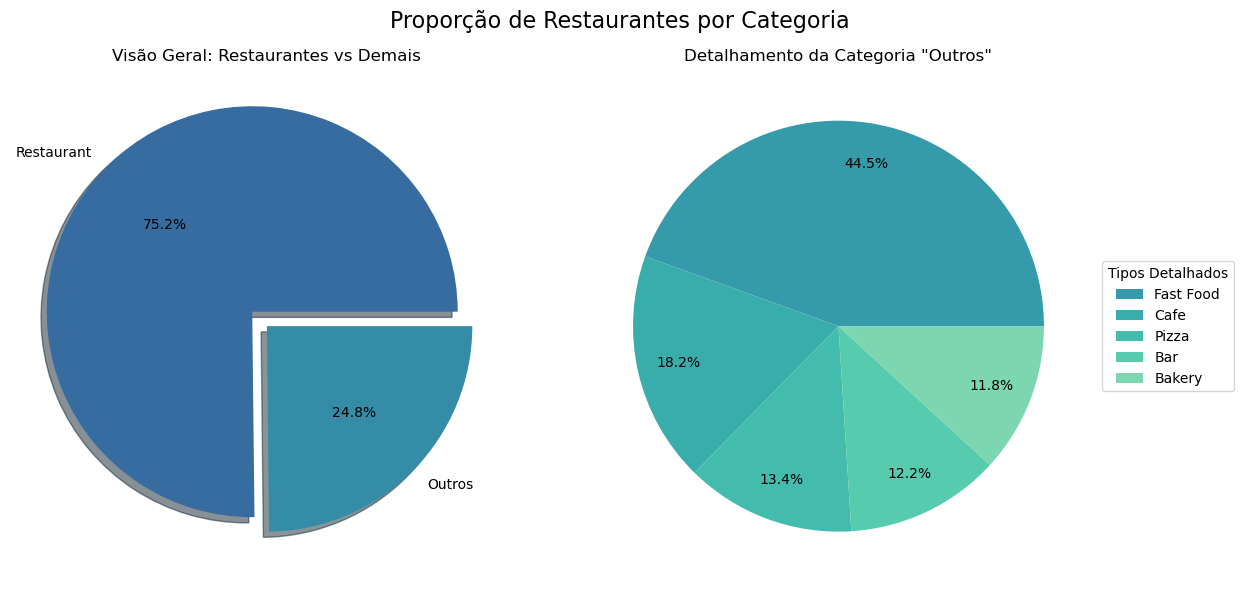

In [8]:
# Preparação dos dados para gráfico
total_others = rest_type[rest_type['object_type'] != 'Restaurant']['count'].sum()
pie1_data = [rest_type.loc[rest_type['object_type'] == 'Restaurant', 'count'].values[0], total_others]
pie1_labels = ['Restaurant', 'Outros']

# Dados para a segunda pizza (apenas o detalhamento dos "Outros")
df_others = rest_type[rest_type['object_type'] != 'Restaurant'].sort_values('count', ascending=False)

# 2. Configurando a figura com dois subplots (1 linha, 2 colunas)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 6))

# Gráfico 1: Restaurant vs Outros
colors1 = ['#366CA0','#348CA7'] # Rosa para Restaurant, Azul para Outros
ax1.pie(
    pie1_data, 
    labels=pie1_labels, 
    autopct='%1.1f%%', 
    startangle=0, 
    colors=colors1, 
    explode=(0.1, 0), # Destaca a fatia Restaurant
    shadow=True
)
ax1.set_title('Visão Geral: Restaurantes vs Demais')

# Gráfico 2: Detalhamento dos Outros
colors2 = ['#359BAA', '#39ACAC', '#44BCAD', '#57CBAD', '#7CD6AF', '#A4E0BB', '#C6EBD1']
patches, texts, autotexts = ax2.pie(
    df_others['count'], 
    autopct='%1.1f%%', 
    startangle=0, # Começa na direita
    colors=colors2,
    pctdistance=0.8
)
ax2.set_title('Detalhamento da Categoria "Outros"')

# Legenda lateral no segundo gráfico para garantir que as fatias pequenas sejam lidas
ax2.legend(
    patches, 
    df_others['object_type'],
    title="Tipos Detalhados",
    loc="center left",
    bbox_to_anchor=(1, 0.5)
)

fig.suptitle('Proporção de Restaurantes por Categoria', fontsize=16)
plt.tight_layout()
plt.show()


Observação: É possível observar que 75,2% dos estabelecimentos em L.A. são restaurantes. Os outros 24,8% dos estabelecimentos se dividem entre as demais categorias. Dentre essa menor fatia das demais categorias, Fast-food representa 44,5%, Cafés são 18,2%, Pizzarias são 13,4%, Bares representam 12,2% e as Padarias são 11,8%.
#### 3.1.2 Proporção de estabelecimentos independentes ou que fazem parte de uma rede

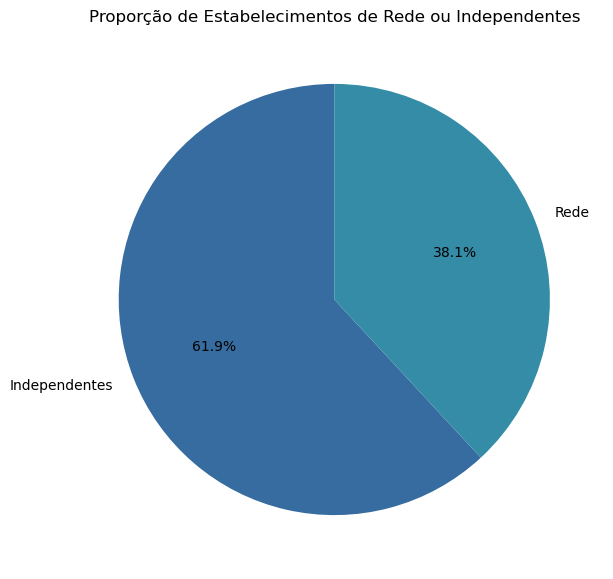

In [9]:
# Entendendo a proporção geral de estabelecimentos de rede ou independentes
rest_prop_chain = df_rest_data.groupby(['chain']).size().reset_index(name='count')

# Mapeando etiquetas de chain para melhor visualização
mapping = {False: 'Independentes', True: 'Rede'}

# Criando gráfico de pizza
plt.figure(figsize=(12, 7))
plt.pie(rest_prop_chain['count'], labels=rest_prop_chain['chain'].map(mapping), colors=colors1, autopct='%1.1f%%', startangle=90)
plt.title('Proporção de Estabelecimentos de Rede ou Independentes')
plt.show()


In [10]:
# Entendendo a proporção de estabelecimentos por ramo e se faz parte de uma rede ou não
rest_type_chain = df_rest_data.groupby(['object_type', 'chain']).size().reset_index(name='count').sort_values('object_type')
rest_type_chain['prop'] = ((rest_type_chain['count'] / rest_type_chain['count'].sum()) * 100).round(2)

# Imprimindo tabela
display(rest_type_chain)

,object_type,chain,count,prop
0,Bakery,True,283,2.93
1,Bar,False,215,2.23
2,Bar,True,77,0.80
3,Cafe,False,169,1.75
4,Cafe,True,266,2.76
5,Fast Food,False,461,4.78
6,Fast Food,True,605,6.27
7,Pizza,False,166,1.72
8,Pizza,True,154,1.60
9,Restaurant,False,4962,51.41


In [11]:
# Transformando os dados para o formato de gráfico (Pivot Table)
pivot_df = rest_type_chain.pivot(index='object_type', columns='chain', values='count').fillna(0)

# Convertendo para proporção (0 a 100%) para cada linha
pivot_df_perc = pivot_df.div(pivot_df.sum(axis=1), axis=0) * 100

# Ordenando pelo tipo que mais tem redes para facilitar a leitura
pivot_df_perc = pivot_df_perc.sort_values(by=True, ascending=False)

# Imprimindo pivot table
pivot_df_perc


chain,False,True
object_type,,
Bakery,0.000000,100.000000
Cafe,38.850575,61.149425
Fast Food,43.245779,56.754221
Pizza,51.875000,48.125000
Restaurant,68.394211,31.605789
Bar,73.630137,26.369863


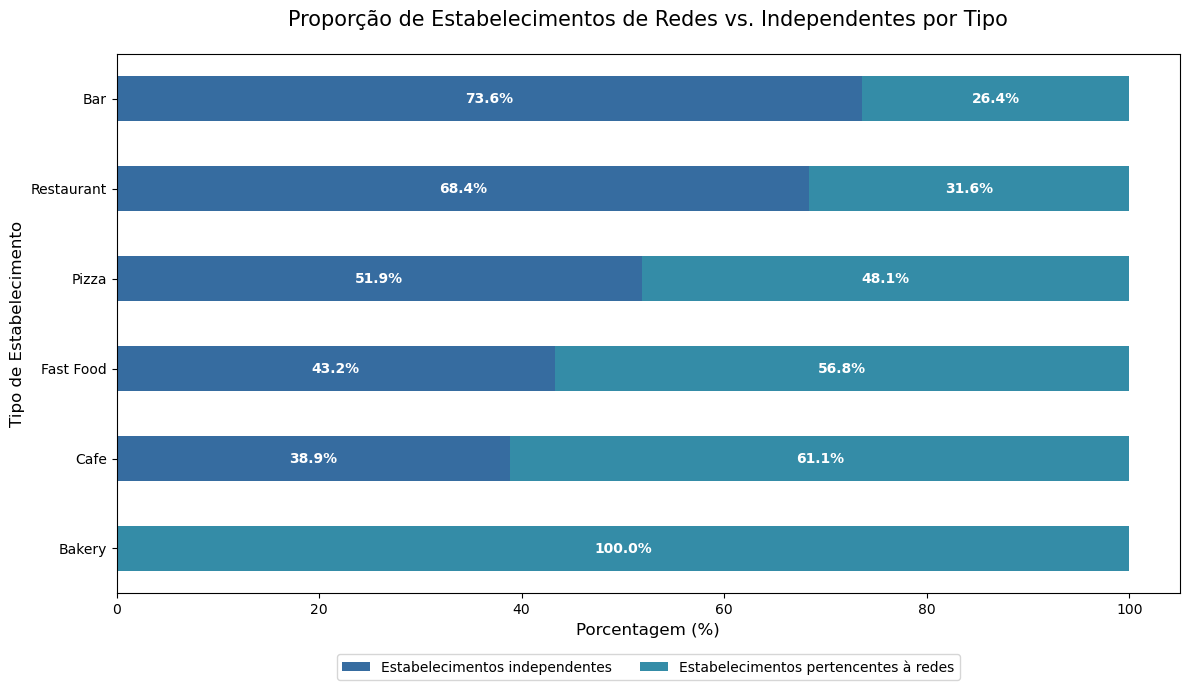

In [12]:
# Criando o gráfico de barras empilhadas
ax = pivot_df_perc.plot(
    kind='barh', # barras horizontais, tornando melhor a visualização e comparação entre tipos de estabelecimento
    stacked=True, 
    figsize=(12, 7),
    color=colors1 # Vermelho suave para Não Rede, Azul para Rede
)

# Customizando o gráfico
plt.title('Proporção de Estabelecimentos de Redes vs. Independentes por Tipo', fontsize=15, pad=20)
plt.xlabel('Porcentagem (%)', fontsize=12)
plt.ylabel('Tipo de Estabelecimento', fontsize=12)
plt.legend(['Estabelecimentos independentes', 'Estabelecimentos pertencentes à redes'], loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=2)

# Adicionando os rótulos de porcentagem dentro das barras
for p in ax.patches:
    width = p.get_width()
    if width > 0: # Só desenha se a barra existir
        ax.annotate(f'{width:.1f}%', 
                    (p.get_x() + width / 2, p.get_y() + p.get_height() / 2),
                    ha='center', va='center', color='white', fontweight='bold')

plt.tight_layout()
plt.show()


Observações: Ao analisar cada categoria para entender sua representatividade em relação a fazer parte ou não de uma rede, é possível observar que, proporcionalmente, os bares são, em sua maioria, estabelecimentos independentes (73,6%) e que todas (100%) as padarias fazem parte de alguma rede. É possível observar também que os Restaurantes são, em sua maioria (68,4%) estabelecimentos independentes, enquanto que os cafés são, em sua maioria (61,1%), estabelecimentos pertencentes a alguma rede.
### 3.2 Dinâmica de Redes (chains)
Aqui vamos entender o que caractariza redes em termos de número de estabelecimentos e número de assentos.

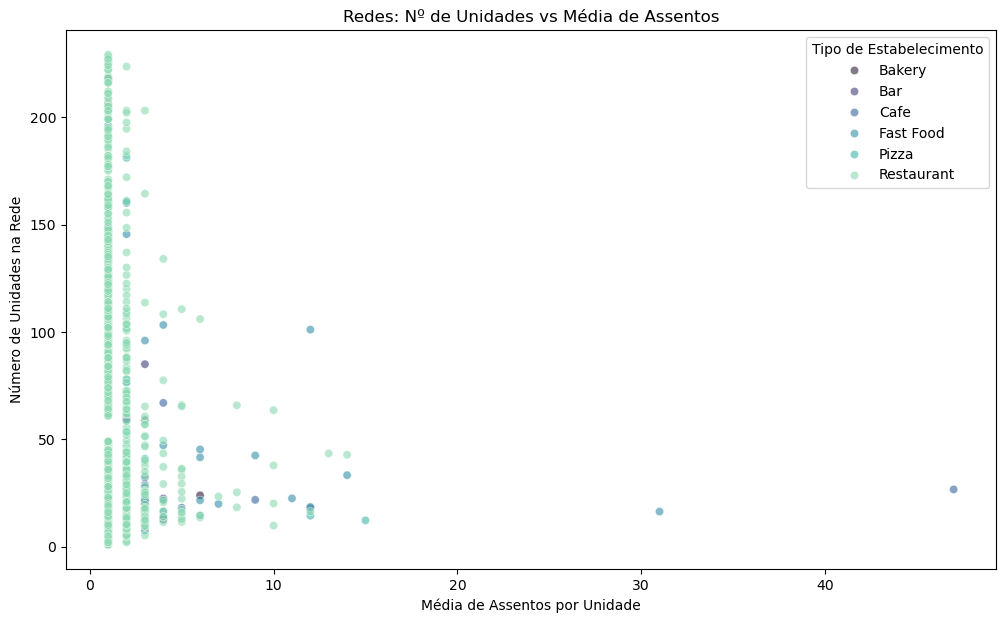

In [13]:
# Filtrando apenas estabelecimentos de rede 
rest_chain = df_rest_data[df_rest_data['chain'] == True]
rest_chain = rest_chain.drop(axis=1, labels='chain')

# Agrupando por tipo de estabelecimento
chain_stats = rest_chain.groupby(['object_type', 'object_name']).agg({'id': 'count',
                                                     'number': 'mean'
                                                     }).reset_index().rename(columns=
                                                                             {'id': 'unit_count',
                                                                              'number': 'avg_seats'})
                                                     

# Criando gráfico de dispersão
plt.figure(figsize=(12, 7))
sns.scatterplot(data=chain_stats, x='unit_count', y='avg_seats', alpha=0.6, hue='object_type', palette='mako')
plt.title('Redes: Nº de Unidades vs Média de Assentos')
plt.xlabel('Média de Assentos por Unidade')
plt.ylabel('Número de Unidades na Rede')
plt.legend(title='Tipo de Estabelecimento')
plt.show()


Observações: é possível observar que as unidades pertencentes a redes preferem um número reduzido de assentos, uma vez que a grande maioria das unidades apresentam menos que 10 assentos em média. É possível observar também que a maior quantidade de estabelecimentos apresentam baixo número de assentos, sinalizando que estabelecimentos de rede tendem a ser numerosos, porém, com baixa capacidade de assentos.

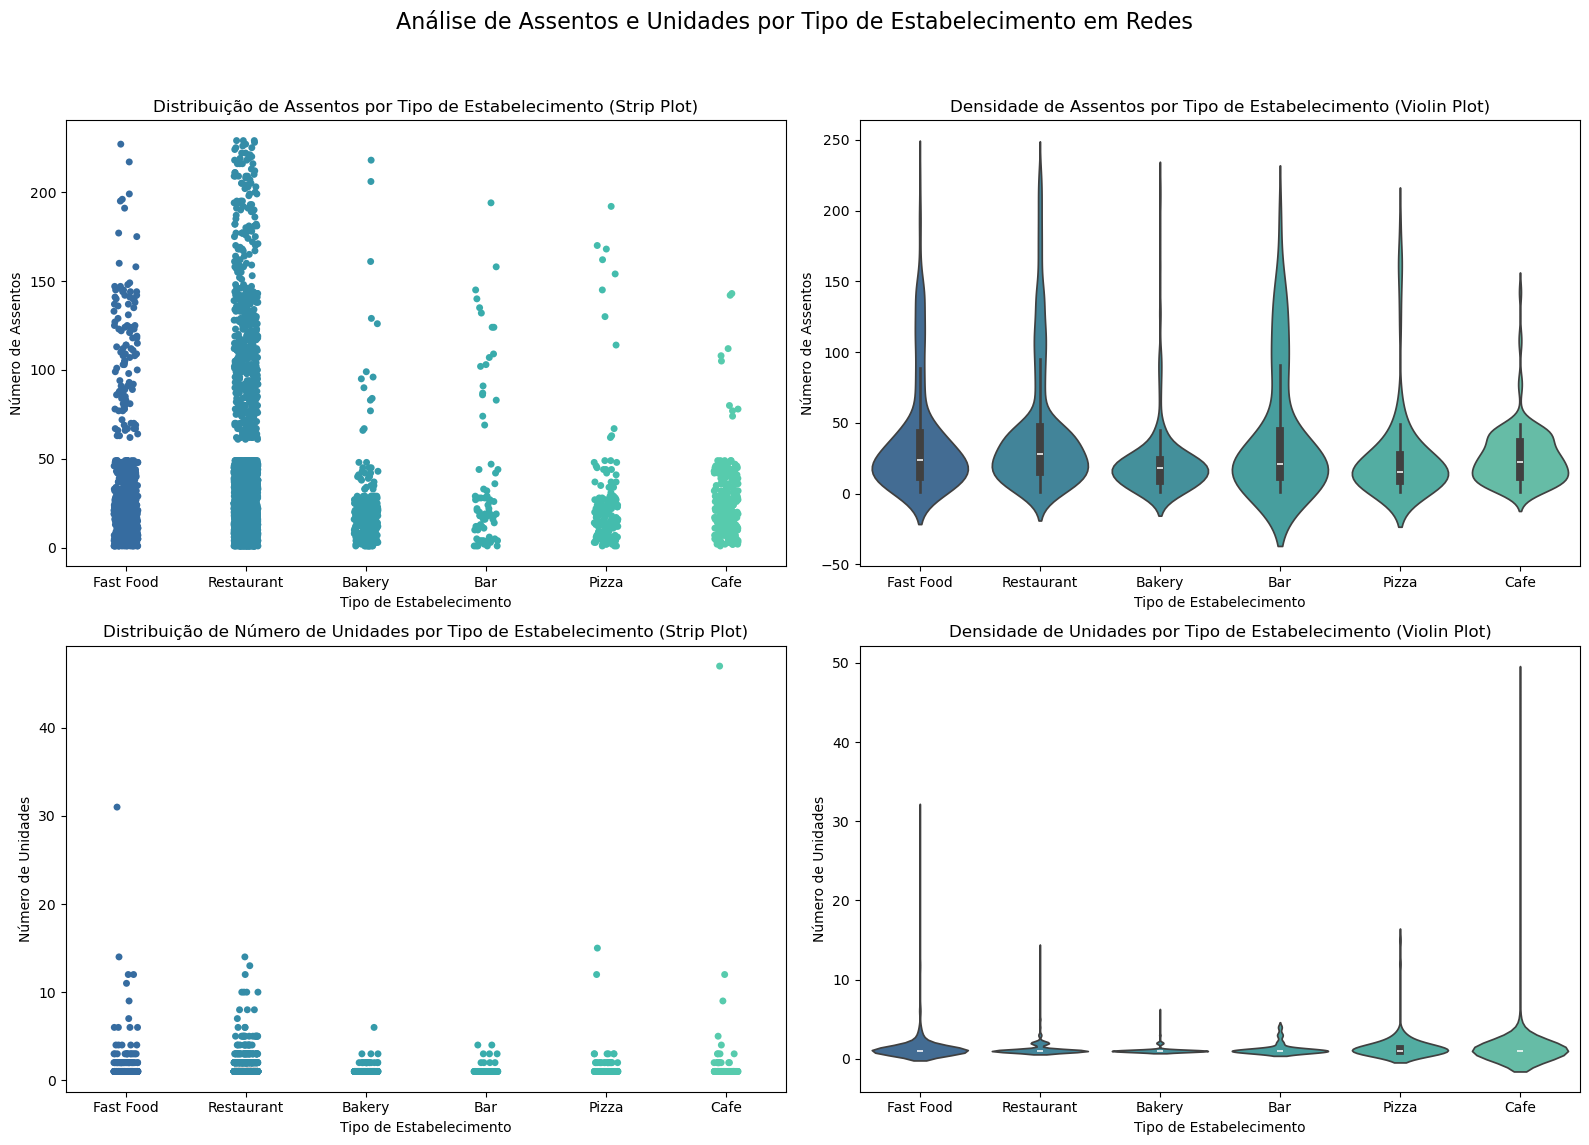

In [14]:
# Configurando a figura com dois subplots (1 linha, 2 colunas)
fig, ([ax1, ax2], [ax3, ax4]) = plt.subplots(2, 2, figsize=(16, 12))

# Padronizando cores por tipo de estabelecimento nos gráficos
colors3 = ['#366CA0','#348CA7', '#359BAA', '#39ACAC', '#44BCAD', '#57CBAD', '#7CD6AF', '#A4E0BB', '#C6EBD1', '#D0EFD9']
rest_order = rest_chain['object_type'].unique() # Mantem ordem de categorias para manter as cores nos gráficos
fixed_colors = dict(zip(rest_order, sns.color_palette(colors3, n_colors=len(rest_order))))

# Gráfico 1: Strip Plot
sns.stripplot(
    x='object_type', 
    y='number', 
    data=rest_chain, 
    ax=ax1, 
    hue='object_type', 
    order=rest_order, 
    palette=fixed_colors, 
    legend=False
    )

ax1.set_title('Distribuição de Assentos por Tipo de Estabelecimento (Strip Plot)')
ax1.set_xlabel('Tipo de Estabelecimento')
ax1.set_ylabel('Número de Assentos')

# Gráfico 2: Violin Plot
sns.violinplot(
    x='object_type', 
    y='number',
    data=rest_chain,
    ax=ax2,
    hue='object_type',
    order=rest_order,
    palette=fixed_colors,
    legend=False
    )

ax2.set_title('Densidade de Assentos por Tipo de Estabelecimento (Violin Plot)')
ax2.set_xlabel('Tipo de Estabelecimento')
ax2.set_ylabel('Número de Assentos')

# Gráfico 3: Strip Plot
sns.stripplot(
    x='object_type', 
    y='unit_count', 
    data=chain_stats, 
    ax=ax3, 
    hue='object_type', 
    order=rest_order, 
    palette=fixed_colors, 
    legend=False
    )

ax3.set_title('Distribuição de Número de Unidades por Tipo de Estabelecimento (Strip Plot)')
ax3.set_xlabel('Tipo de Estabelecimento')
ax3.set_ylabel('Número de Unidades')

# Gráfico 4: Violin Plot
sns.violinplot(
    x='object_type', 
    y='unit_count', 
    data=chain_stats, 
    ax=ax4, 
    hue='object_type', 
    order=rest_order, 
    palette=fixed_colors, 
    legend=False
    )

ax4.set_title('Densidade de Unidades por Tipo de Estabelecimento (Violin Plot)')
ax4.set_xlabel('Tipo de Estabelecimento')
ax4.set_ylabel('Número de Unidades')

fig.suptitle('Análise de Assentos e Unidades por Tipo de Estabelecimento em Redes', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


Observações: Os tipos de estabelecimentos pertencentes a redes apresentam menos de 50 assentos em sua maioria. Os tipos Restaurante, Fast-Food e Bar apresentam uma quantidade um pouco maior de estabelecimentos apresentando de 50 a 150 assentos, mas ainda assim, tem a maioria dos seus estabelecimentos com menos de 50. Dessa maneira, podemos afirmar que os estabelecimentos pertencentes a redes são, em sua maioria, numerosos e com baixa capacidade de assentos.
### 3.3 Capacidade de Estabelecimentos
Agora vamos entender que tipo de estabelecimento tem o maior e o menor número de assentos em média.

In [15]:
# Entendendo média de assentos por tipo de estabelecimento
rest_avg_seats = df_rest_data.groupby('object_type').agg({'number': 'mean'}).reset_index().rename(columns={'number': 'avg_seats'})
rest_avg_seats_chain = df_rest_data.groupby(['object_type', 'chain']).agg({'number': 'mean'}).reset_index().rename(columns={'number': 'avg_seats'}).sort_values(by='avg_seats', ascending=False)
pivot_avg_seats_chain = pd.pivot_table(rest_avg_seats_chain, index=['object_type'], columns=['chain'], values=['avg_seats']).fillna(0)

# Imprimindo tabela
display(rest_avg_seats)
display(pivot_avg_seats_chain)

,object_type,avg_seats
0,Bakery,21.773852
1,Bar,44.767123
2,Cafe,25.000000
3,Fast Food,31.837711
4,Pizza,28.459375
5,Restaurant,48.042316


avg_seats           
chain            False      True 
object_type                      
Bakery        0.000000  21.773852
Bar          46.381395  40.259740
Cafe         23.556213  25.917293
Fast Food    23.633406  38.089256
Pizza        31.325301  25.370130
Restaurant   49.520959  44.842564

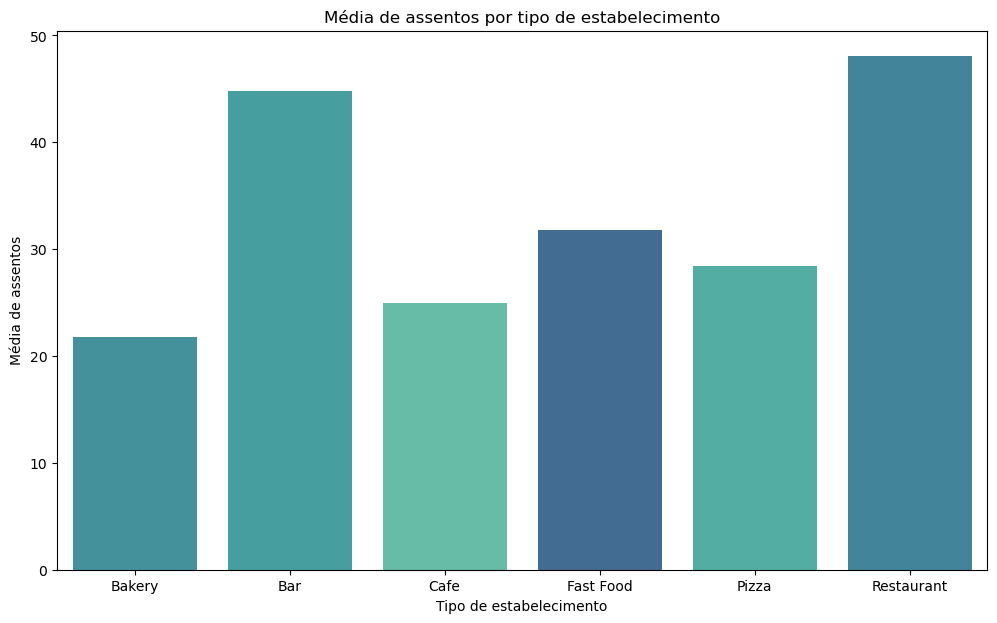

In [16]:
# Criando gráfico de barras para média de assentos por tipo de estabelecimento
plt.figure(figsize=(12, 7))
sns.barplot(data=rest_avg_seats, x='object_type', y='avg_seats', palette=fixed_colors, hue='object_type')
plt.title('Média de assentos por tipo de estabelecimento')
plt.ylabel('Média de assentos')
plt.xlabel('Tipo de estabelecimento')
plt.show()


Observações: De maneira geral, os Restaurantes são os tipos de estabelecimentos que possuem mais assentos em média, seguido dos Bares e de Fast-food. Vamos ver se esse padrão se repete quando comparamos as médias dos estabelecimentos pertencentes à redes ou não.

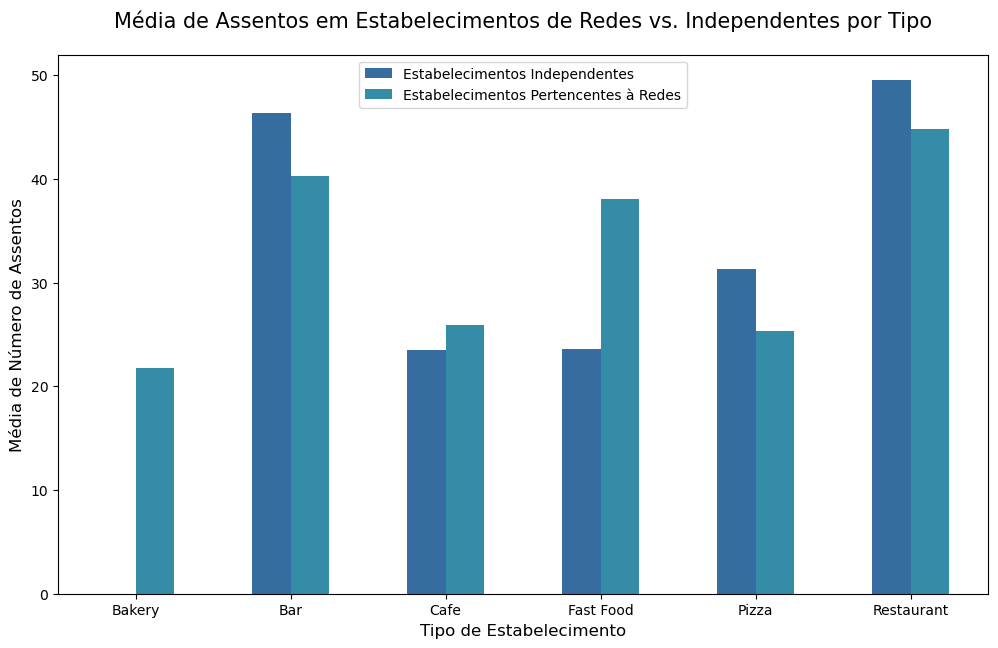

In [17]:
# Criando gráfico de barras com média de assentos comparando estabelecimentos de rede e independentes
ax = pivot_avg_seats_chain.plot(
    kind='bar', 
    figsize=(12, 7),
    color=colors1
    )

# Customizando o gráfico
plt.title('Média de Assentos em Estabelecimentos de Redes vs. Independentes por Tipo', fontsize=15, pad=20)
plt.xlabel('Tipo de Estabelecimento', fontsize=12)
plt.ylabel('Média de Número de Assentos', fontsize=12)
plt.legend(['Estabelecimentos Independentes', 'Estabelecimentos Pertencentes à Redes'], loc='upper center')
plt.xticks(rotation=0)
plt.show()


Observações: Ao estratificarmos os dados entre estabelecimentos independentes e aqueles pertencentes à redes, o padrão não muda: os restaurantes possuem o maior número de assentos em média, seguido dos Bares. Redes de fast-food tem média de número de assentos maior comparado à média de independentes da categoria.
### 3.4 Análise Espacial/Geográfica
Agora vamos entender a dinâmica dos estabelecimentos de maneira espacial, verificando ruas que possuem muitos ou poucos estabelecimentos. Aqui vamos:
- Identificar as 10 ruas com maior número de estabelecimentos;
- Encontrar possíveis ruas com somente 1 estabelecimento;
- Observar número de assentos de estabelecimentos localizados nas ruas com maior número de estabelecimentos e verificar se há alguma tendência.

In [18]:
# Encontrando as 10 ruas com mais estabelecimentos
top_10_streets = df_rest_data['street_name'].value_counts().sort_values(ascending=False).head(10)

# Filtrando data frame original somente com os dados das empresas nas 10 ruas mais com mais estabelecimentos
df_top_10_streets = df_rest_data[df_rest_data['street_name'].isin(top_10_streets.index)]

# Encontrando número de ruas com apenas um estabelecimento
one_rest_count = (df_rest_data['street_name'].value_counts() == 1).sum()

# Imprimindo número de ruas com apenas um estabelecimento
print(f"Número de ruas com apenas um estabelecimento: {one_rest_count}")

Número de ruas com apenas um estabelecimento: 334


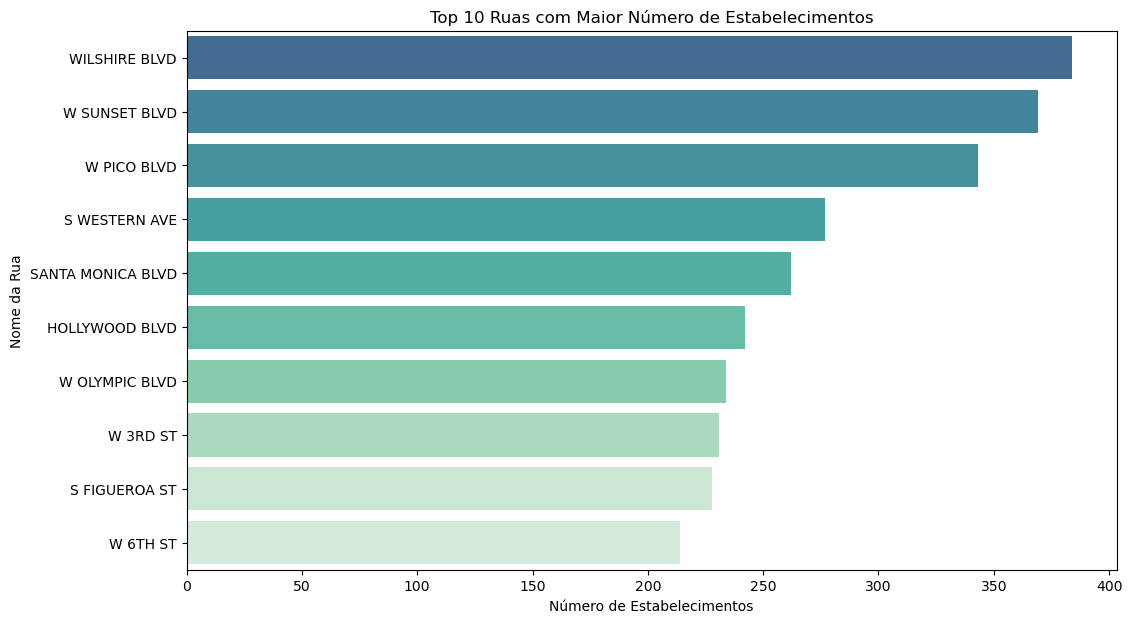

In [19]:
# Padronizando cores por rua nos gráficos
top_streets_fixed_colors = dict(zip(top_10_streets.index, sns.color_palette(colors3, n_colors=len(top_10_streets.index))))

# Gerando gráfico de barras com número de estabelecimentos nas 10 ruas mais populares
plt.figure(figsize=(12, 7))
sns.barplot(x=top_10_streets.values, y=top_10_streets.index, palette=top_streets_fixed_colors, hue=top_10_streets.index)
plt.title('Top 10 Ruas com Maior Número de Estabelecimentos')
plt.xlabel('Número de Estabelecimentos')
plt.ylabel('Nome da Rua')
plt.show()


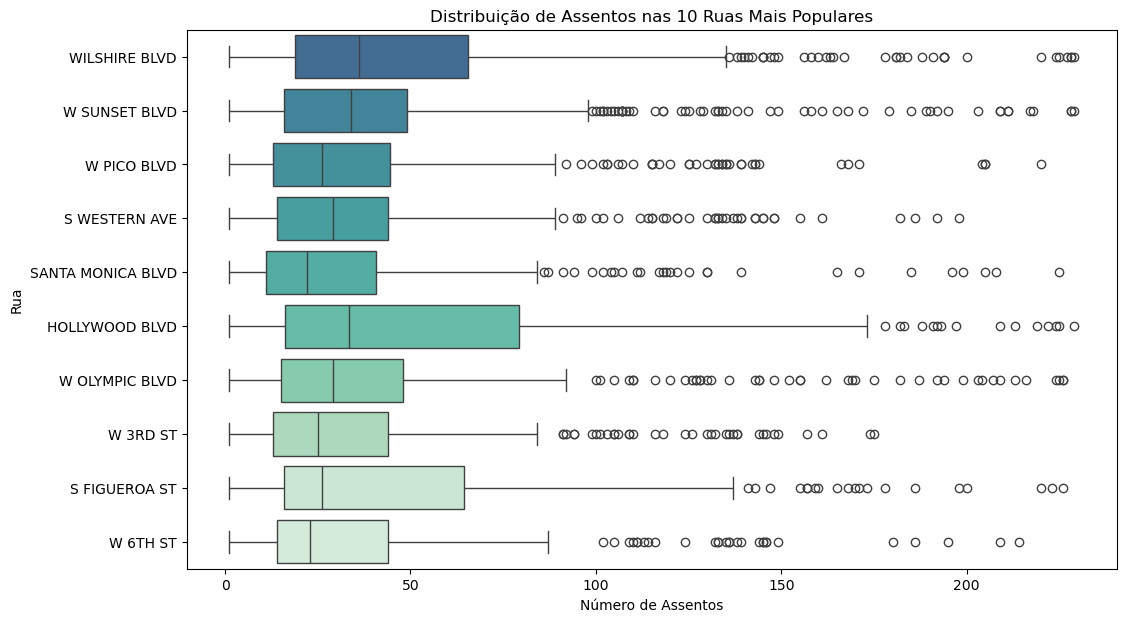

In [20]:
# Gerando gráficos boxplot de distribuição de assentos nas 10 ruas com mais estabelecimentos
plt.figure(figsize=(12, 7))
sns.boxplot(data=df_top_10_streets, x='number', y='street_name', hue='street_name', order=top_10_streets.index, palette=top_streets_fixed_colors)
plt.title('Distribuição de Assentos nas 10 Ruas Mais Populares')
plt.xlabel('Número de Assentos')
plt.ylabel('Rua')
plt.show()


Observações: Além de somente existirem $334$ ruas que possuem apenas um único estabelecimento registrado no conjunto de dados, as 10 ruas contendo o maior número de estabelecimentos apresentam uma grande quantidade de outliers, contendo estabelecimentos com mais de 150 assentos. Isso nos sugere que essas regiões podem ser bastante movimentadas por clientes e, portanto, comportam grandes estabelecimentos com grande número de assentos para suprir a demanda.
## 4 Conclusões Estratégicas
Com base na análise exploratória do mercado gastronômico de Los Angeles, as seguintes diretrizes são propostas para a viabilização da cafeteria com garçons robóticos:

- Tipo de Estabelecimento e Escala: Embora os restaurantes dominem o cenário (75,17%), as cafeterias representam um nicho de 4,51%. O projeto deve se posicionar como um "Café" de médio a grande porte. A análise das ruas mais populares revelou a presença de estabelecimentos com mais de 150 assentos para suprir o alto fluxo de clientes, sugerindo que o modelo de robôs é ideal para locais de alta rotatividade, onde a eficiência operacional é crucial.

- Localização Premium: A estratégia deve focar em uma das 10 ruas com maior densidade de estabelecimentos (como a W Sunset Blvd ou Figueroa St), onde a alta concentração de concorrentes e o fluxo intenso de pedestres justificam o investimento em tecnologia para atrair e reter o público através do fator novidade.

- Mitigação de Riscos: O "efeito novidade" dos robôs deve ser utilizado como alavanca inicial de marketing. No entanto, para garantir a rentabilidade a longo prazo, o foco deve migrar gradualmente para a eficiência logística e qualidade do produto. A robótica não deve ser apenas um espetáculo, mas uma solução para reduzir custos operacionais e volatividade de mão de obra em áreas de alto custo em LA.

- Expansão e Rede: Dado que redes de estabelecimentos são comuns em áreas movimentadas, o projeto piloto deve ser desenhado para ser escalável. Uma vez validada a eficiência operacional dos garçons robôs, o modelo poderá ser replicado em outras regiões estratégicas da cidade, aproveitando a familiaridade do público de LA com soluções "high-tech".

Em suma, Los Angeles oferece o terreno ideal para este projeto, unindo um público ávido por inovação tecnológica a um mercado com demanda comprovada em regiões de alta densidade comercial.
## Apresentação para Investidores
Segue link do arquivo em PDF contendo a apresentação para investidores:

Presentation: <https://1drv.ms/b/c/835153c0338453fe/IQApNPupqOIbT60SjkNkAm9mAbrVJjvht91UVXZvwobXx50?e=19Pf8e>